# Data cleaning diagnostics
Correlation matrix, observation counts and pairwise overlap of the raw monthly returns.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # project root, so `src` and `scripts` import

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scripts.cleaning_diagnostics import main
from src.config import (
    DUPLICATE_CORRELATION,
    MIN_OBSERVATIONS,
    PROCESSED_DATA_DIR,
)

main()  # regenerates the CSVs below from the raw data

    n_obs first_date  last_date  zero_share asset_class
AP     75 2008-10-31 2014-12-31    0.000000          EQ
XX    149 2002-07-31 2014-11-28    0.000000          EQ
YM    152 2002-05-31 2014-12-31    0.000000          EQ
XU    164 2001-04-30 2014-11-28    0.006098          EQ
UZ    190 1999-02-26 2014-11-28    0.015789          FI
UB    190 1999-02-26 2014-11-28    0.000000          FI
CA    191 1999-02-26 2014-12-31    0.000000          EQ
ZD    200 1998-05-29 2014-12-31    0.000000          EQ
AX    204 1997-12-31 2014-11-28    0.000000          EQ
HS    204 1997-11-28 2014-12-31    0.000000          EQ
DA    207 1997-10-31 2014-12-31    0.009662        COMM
ND    224 1996-05-31 2014-12-31    0.000000          EQ
MP    235 1995-06-30 2014-12-31    0.008511          FX
CB    246 1994-07-29 2014-12-31    0.000000          FI
SS    261 1991-10-31 2014-12-31    0.026820          FI
RL    262 1993-03-31 2014-12-31    0.007634          EQ
MD    274 1992-03-31 2014-12-31    0.000000     

In [2]:
corr = pd.read_csv(PROCESSED_DATA_DIR / "correlation_matrix.csv", index_col=0)
counts = pd.read_csv(PROCESSED_DATA_DIR / "data_counts.csv", index_col=0, parse_dates=["first_date", "last_date"])
overlap = pd.read_csv(PROCESSED_DATA_DIR / "pairwise_overlap.csv", index_col=0)

# order markets by asset class, then by ID, so blocks of related markets sit together
order = counts.reset_index().sort_values(["asset_class", "index"])["index"].tolist()
classes = counts.loc[order, "asset_class"]

## Correlation matrix
Markets grouped by asset class (COMM, EQ, FI, FX). Pairs with under 36 shared months are blank.

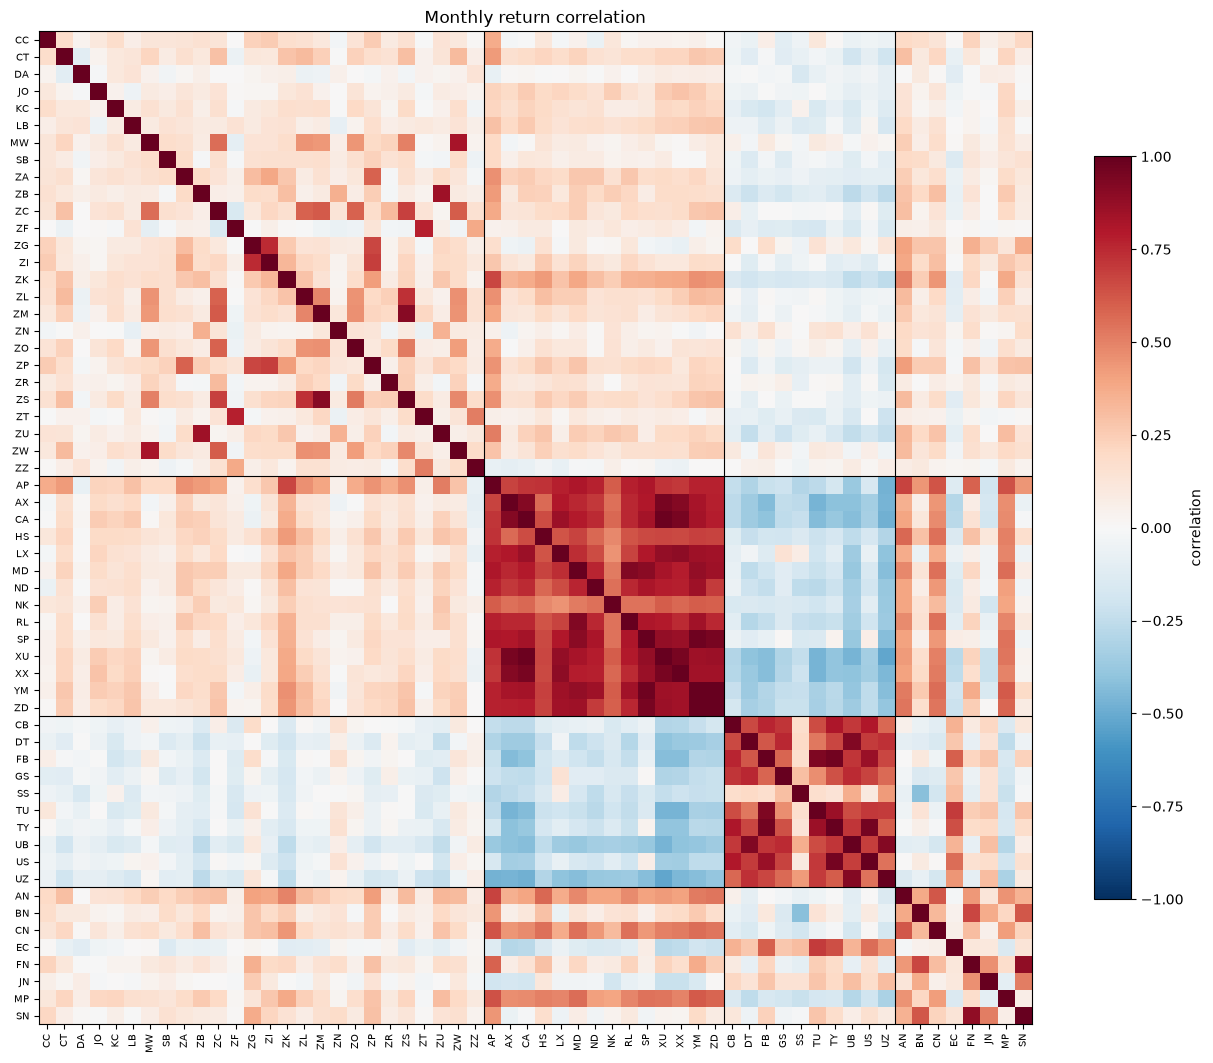

In [3]:
def heatmap(matrix, title, cmap, vmin, vmax, label):
    m = matrix.loc[order, order]
    fig, ax = plt.subplots(figsize=(13, 11))
    im = ax.imshow(m.to_numpy(dtype=float), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(order)), order, rotation=90, fontsize=7)
    ax.set_yticks(range(len(order)), order, fontsize=7)
    for edge in np.flatnonzero(classes.to_numpy()[1:] != classes.to_numpy()[:-1]) + 0.5:
        ax.axhline(edge, color="black", lw=0.8)
        ax.axvline(edge, color="black", lw=0.8)
    fig.colorbar(im, ax=ax, shrink=0.7, label=label)
    ax.set_title(title)
    fig.tight_layout()
    return fig

heatmap(corr, "Monthly return correlation", "RdBu_r", -1, 1, "correlation");

### Most correlated pairs
Only pairs at or above the duplicate threshold are merged.

In [4]:
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack().rename("corr").to_frame()
upper["overlap"] = [overlap.loc[a, b] for a, b in upper.index]
top = upper.sort_values("corr", ascending=False).head(15)
top["merged"] = top["corr"] >= DUPLICATE_CORRELATION
top

,,corr,overlap,merged
YM,ZD,0.999968,152,True
CA,XU,0.976599,164,False
SP,YM,0.972547,152,False
FB,TY,0.968228,311,False
TY,US,0.954518,383,False
XU,XX,0.952176,149,False
CA,XX,0.947360,149,False
SP,ZD,0.946123,200,False
AX,XU,0.946020,164,False
FB,TU,0.933905,291,False


## Observation counts
Bars colored by asset class; the dashed line is the minimum observation threshold.

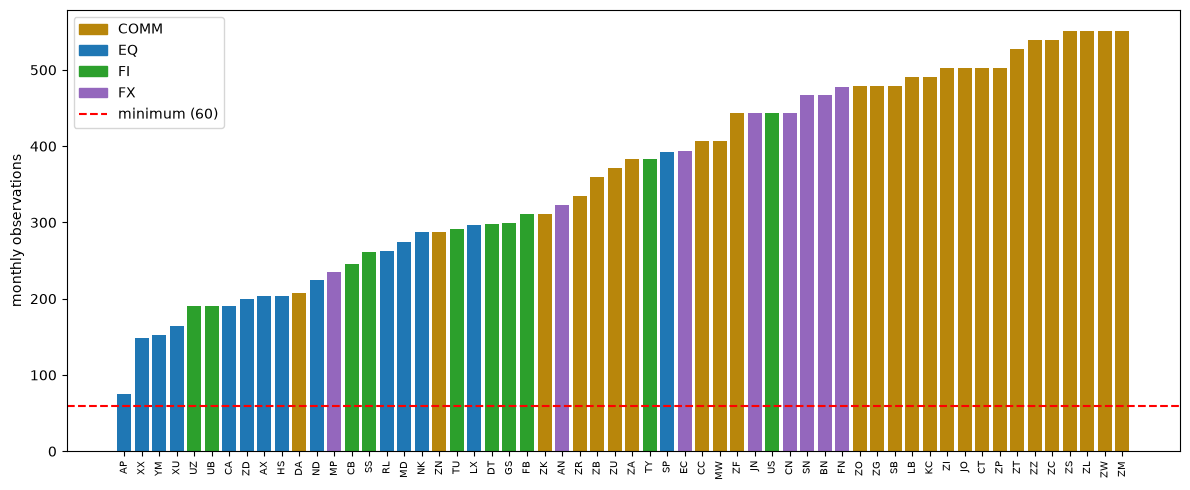

In [5]:
palette = {"COMM": "#b8860b", "EQ": "#1f77b4", "FI": "#2ca02c", "FX": "#9467bd"}
c = counts.sort_values("n_obs")
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(c.index, c["n_obs"], color=[palette[a] for a in c["asset_class"]])
ax.axhline(MIN_OBSERVATIONS, ls="--", color="red", label=f"minimum ({MIN_OBSERVATIONS})")
ax.set_ylabel("monthly observations")
ax.tick_params(axis="x", rotation=90, labelsize=7)
handles = [plt.Rectangle((0, 0), 1, 1, color=col) for col in palette.values()]
ax.legend(handles + [ax.lines[0]], [*palette, ax.lines[0].get_label()])
fig.tight_layout();

## Data availability over time
Each row is a market; dark where it has a return.

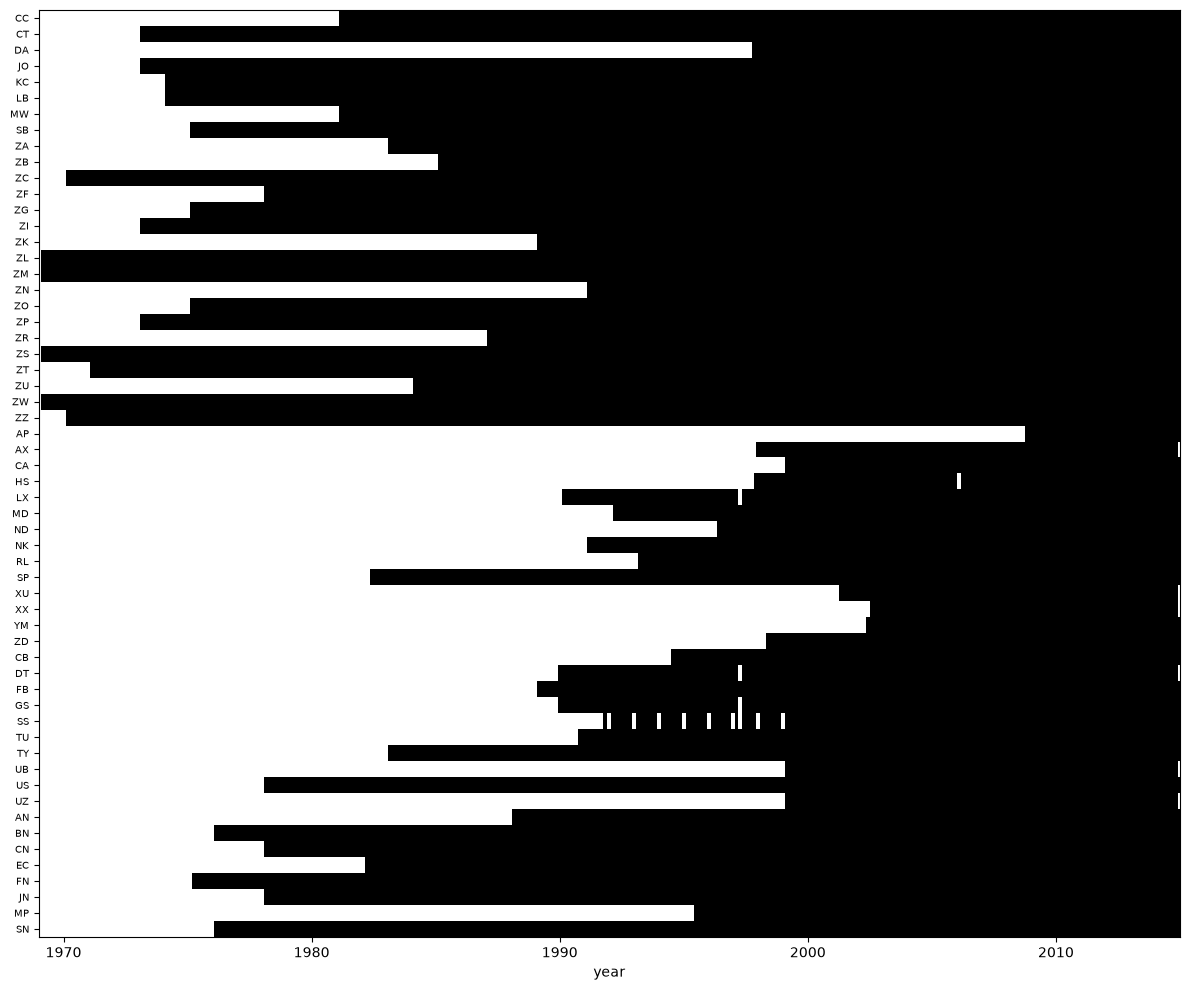

In [6]:
from src.data_loader import load_monthly_returns

returns = load_monthly_returns()[order]
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(returns.notna().T.to_numpy(), aspect="auto", interpolation="nearest", cmap="Greys",
          extent=[mdates_start := returns.index[0].year, returns.index[-1].year + 1, len(order), 0])
ax.set_yticks(np.arange(len(order)) + 0.5, order, fontsize=7)
ax.set_xlabel("year")
fig.tight_layout();

## Pairwise overlap
Shared months per pair; correlations are only as reliable as this.

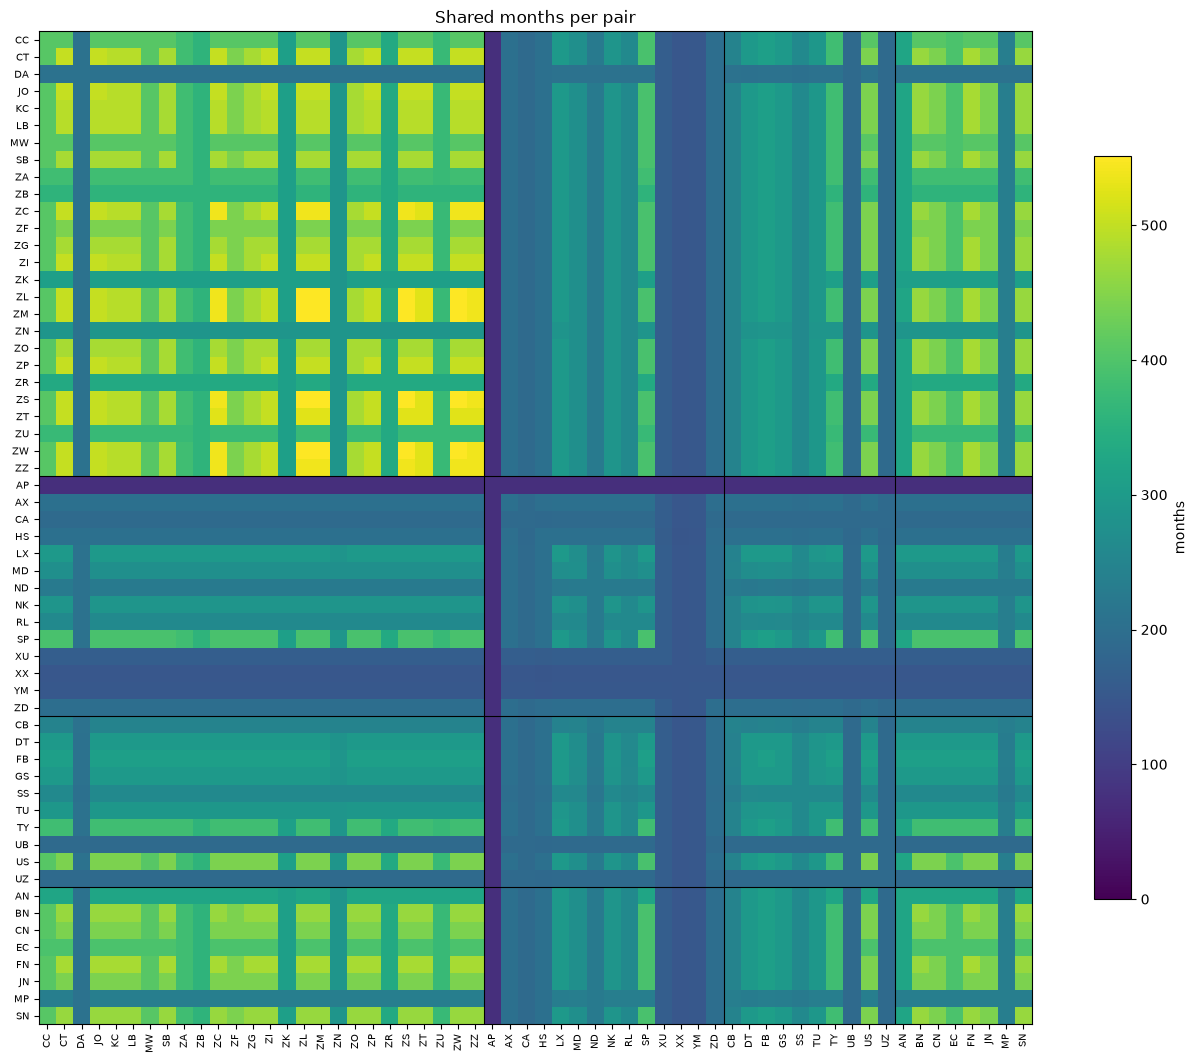

In [7]:
heatmap(overlap, "Shared months per pair", "viridis", 0, overlap.to_numpy().max(), "months");

## Counts table

In [8]:
counts

,n_obs,first_date,last_date,zero_share,asset_class
AP,75,2008-10-31,2014-12-31,0.000000,EQ
XX,149,2002-07-31,2014-11-28,0.000000,EQ
YM,152,2002-05-31,2014-12-31,0.000000,EQ
XU,164,2001-04-30,2014-11-28,0.006098,EQ
UZ,190,1999-02-26,2014-11-28,0.015789,FI
UB,190,1999-02-26,2014-11-28,0.000000,FI
CA,191,1999-02-26,2014-12-31,0.000000,EQ
ZD,200,1998-05-29,2014-12-31,0.000000,EQ
AX,204,1997-12-31,2014-11-28,0.000000,EQ
HS,204,1997-11-28,2014-12-31,0.000000,EQ
